# Variables aleatorias, distribuciones, simulación, FGM, FC, LGN y TCL

## 0. Preparación del ambiente

Primero importamos las librerías necesarias. Se usará:

- `numpy` para simulación y cálculo numérico.
- `pandas` para tablas.
- `matplotlib` para gráficas.
- `scipy.stats` para distribuciones de probabilidad.
- `sympy` para derivar funciones generadoras y obtener momentos simbólicamente.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sympy as sp

# Semilla para que las simulaciones sean reproducibles.
np.random.seed(123)

# Configuración general de gráficas.
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## 1. Variables aleatorias

Una **variable aleatoria** es una función que asigna un número real a cada resultado de un experimento aleatorio.

Si $\Omega$ es el espacio muestral, una variable aleatoria se puede escribir como:

$$
X:\Omega \to \mathbb{R}.
$$

Esto permite transformar resultados cualitativos o eventos del experimento en valores numéricos que pueden analizarse mediante probabilidades, esperanza, varianza y distribuciones.

Las variables aleatorias se clasifican principalmente en:

- **Discretas**, cuando toman valores finitos o numerables.
- **Continuas**, cuando pueden tomar valores dentro de intervalos de la recta real.

### 1.1 Ejemplo introductorio: suma de dos dados

Al lanzar dos dados, el espacio muestral está formado por pares ordenados:

$$
\Omega=\{(1,1),(1,2),\ldots,(6,6)\}.
$$

Podemos definir la variable aleatoria:

$$
X=\text{suma de los dos dados}.
$$

Aunque el resultado original del experimento es un par, la variable aleatoria lo transforma en un número.

In [21]:
# Espacio muestral de dos dados.
omega = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]

# Variable aleatoria X: suma de los dos dados.
X = {resultado: sum(resultado) for resultado in omega}

# Mostramos algunos valores.
list(X.items())[:10]

[((1, 1), 2),
 ((1, 2), 3),
 ((1, 3), 4),
 ((1, 4), 5),
 ((1, 5), 6),
 ((1, 6), 7),
 ((2, 1), 3),
 ((2, 2), 4),
 ((2, 3), 5),
 ((2, 4), 6)]

## 2. Variables aleatorias discretas

Una variable aleatoria discreta toma valores en un conjunto finito o numerable. Su distribución se describe mediante una **función de probabilidad** o **función de masa de probabilidad**:

$$
p_X(x)=P(X=x).
$$

Para que sea una función de probabilidad válida debe cumplir:

$$
p_X(x)\geq 0
$$

y

$$
\sum_x p_X(x)=1.
$$

A continuación se presentan las distribuciones discretas mínimas solicitadas. Cada una se separa como subsubtema.

### 2.1 Uniforme discreta

Una variable aleatoria tiene distribución **uniforme discreta** cuando todos los valores posibles tienen la misma probabilidad.

Si:

$$
X\in\{a,a+1,\ldots,b\},
$$

entonces:

$$
P(X=x)=\frac{1}{b-a+1}, \qquad x=a,a+1,\ldots,b.
$$

**Propiedades:**

- Todos los valores del soporte son equiprobables.
- Es útil cuando no hay razón para favorecer un resultado sobre otro.
- El soporte es finito.

**Esperanza:**

$$
E(X)=\frac{a+b}{2}.
$$

**Varianza:**

Si $n=b-a+1$,

$$
Var(X)=\frac{n^2-1}{12}.
$$

**Ejercicio adicional:** si se lanza un dado justo, calcular $P(X\geq 5)$.

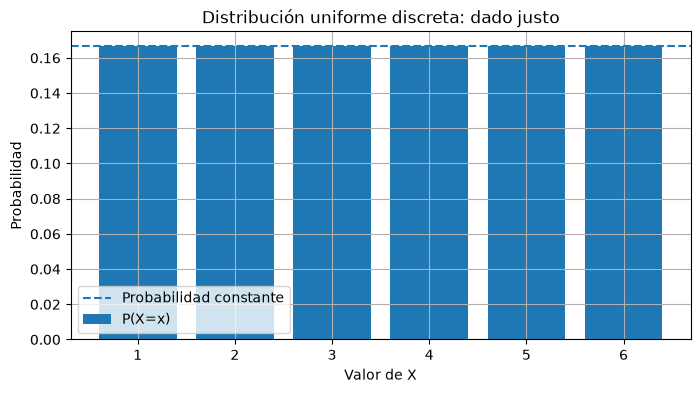

P(X >= 5) = 0.3333
E(X) teórica = 3.5000
Var(X) teórica = 2.9167


In [22]:
# Uniforme discreta: lanzamiento de un dado justo.
a, b = 1, 6
valores = np.arange(a, b + 1)
probabilidades = np.repeat(1 / len(valores), len(valores))

# Ejercicio adicional: P(X >= 5)
prob_mayor_igual_5 = probabilidades[valores >= 5].sum()

plt.figure()
plt.bar(valores, probabilidades, label="P(X=x)")
plt.axhline(1 / len(valores), linestyle="--", label="Probabilidad constante")
plt.title("Distribución uniforme discreta: dado justo")
plt.xlabel("Valor de X")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X >= 5) = {prob_mayor_igual_5:.4f}")
print(f"E(X) teórica = {(a + b) / 2:.4f}")
print(f"Var(X) teórica = {((b - a + 1)**2 - 1) / 12:.4f}")

### 2.2 Bernoulli

Una variable aleatoria **Bernoulli** modela un experimento con dos posibles resultados: éxito o fracaso.

Sea:

$$
X=
\begin{cases}
1, & \text{si ocurre éxito},\\
0, & \text{si ocurre fracaso}.
\end{cases}
$$

Entonces:

$$
P(X=x)=p^x(1-p)^{1-x}, \qquad x=0,1.
$$

**Propiedades:**

- Tiene un solo parámetro $p$.
- Modela un experimento individual con dos resultados.
- Es la base de la distribución binomial.

**Esperanza:**

$$
E(X)=p.
$$

**Varianza:**

$$
Var(X)=p(1-p).
$$

**Ejercicio adicional:** si la probabilidad de que un cliente compre un producto es $0.3$, calcular la esperanza y varianza de la variable que indica compra.

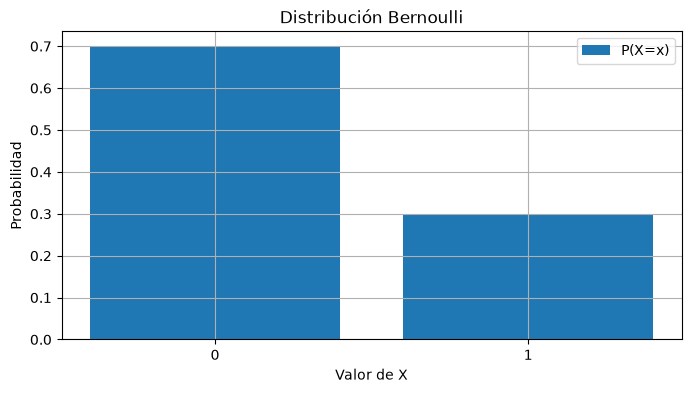

E(X) = 0.3000
Var(X) = 0.2100


In [23]:
# Bernoulli con probabilidad de éxito p.
p = 0.3
x = np.array([0, 1])
pmf = stats.bernoulli.pmf(x, p)

plt.figure()
plt.bar(x, pmf, label="P(X=x)")
plt.title("Distribución Bernoulli")
plt.xlabel("Valor de X")
plt.ylabel("Probabilidad")
plt.xticks(x)
plt.legend()
plt.show()

print(f"E(X) = {p:.4f}")
print(f"Var(X) = {p * (1 - p):.4f}")

### 2.3 Binomial

Una variable aleatoria **binomial** cuenta el número de éxitos en $n$ ensayos Bernoulli independientes con la misma probabilidad de éxito $p$.

Su función de probabilidad es:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},
\qquad k=0,1,\ldots,n.
$$

**Propiedades:**

- Hay $n$ ensayos.
- Cada ensayo tiene dos resultados: éxito o fracaso.
- La probabilidad de éxito $p$ es constante.
- Los ensayos son independientes.

**Esperanza:**

$$
E(X)=np.
$$

**Varianza:**

$$
Var(X)=np(1-p).
$$

**Ejercicio adicional:** si se inspeccionan 10 piezas y cada una tiene probabilidad $0.2$ de ser defectuosa, calcular $P(X=2)$.

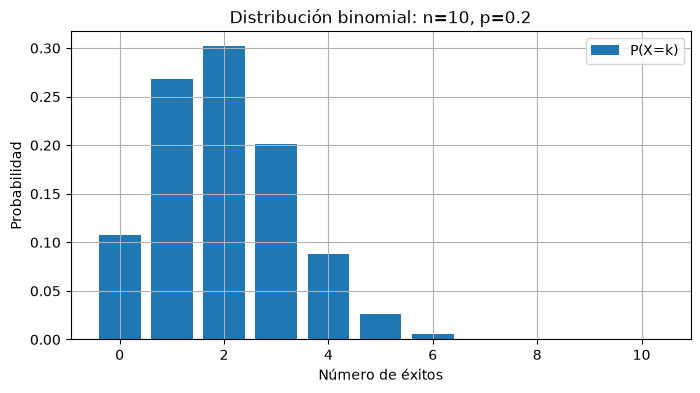

P(X = 2) = 0.3020
E(X) = 2.0000
Var(X) = 1.6000


In [24]:
# Binomial: número de piezas defectuosas en 10 inspecciones.
n, p = 10, 0.2
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

prob_dos_defectuosas = stats.binom.pmf(2, n, p)

plt.figure()
plt.bar(k, pmf, label="P(X=k)")
plt.title("Distribución binomial: n=10, p=0.2")
plt.xlabel("Número de éxitos")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X = 2) = {prob_dos_defectuosas:.4f}")
print(f"E(X) = {n * p:.4f}")
print(f"Var(X) = {n * p * (1 - p):.4f}")

### 2.4 Geométrica

Una variable aleatoria **geométrica** modela el número de ensayos necesarios hasta obtener el primer éxito. Esta versión usa soporte:

$$
X=1,2,3,\ldots
$$

La función de probabilidad es:

$$
P(X=k)=(1-p)^{k-1}p, \qquad k=1,2,3,\ldots
$$

**Propiedades:**

- Los ensayos son independientes.
- La probabilidad de éxito $p$ permanece constante.
- Posee la propiedad de falta de memoria en ensayos discretos.

**Esperanza:**

$$
E(X)=\frac{1}{p}.
$$

**Varianza:**

$$
Var(X)=\frac{1-p}{p^2}.
$$

**Ejercicio adicional:** si la probabilidad de éxito es $0.25$, calcular la probabilidad de que el primer éxito ocurra en el cuarto intento.

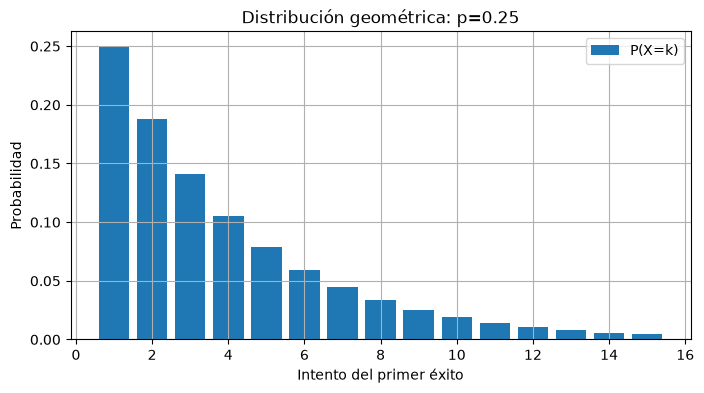

P(X = 4) = 0.1055
E(X) = 4.0000
Var(X) = 12.0000


In [25]:
# Geométrica: número de intentos hasta el primer éxito.
p = 0.25
k = np.arange(1, 16)
pmf = stats.geom.pmf(k, p)

prob_cuarto_intento = stats.geom.pmf(4, p)

plt.figure()
plt.bar(k, pmf, label="P(X=k)")
plt.title("Distribución geométrica: p=0.25")
plt.xlabel("Intento del primer éxito")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X = 4) = {prob_cuarto_intento:.4f}")
print(f"E(X) = {1 / p:.4f}")
print(f"Var(X) = {(1 - p) / p**2:.4f}")

### 2.5 Poisson

La distribución **Poisson** modela el número de ocurrencias de un evento en un intervalo fijo de tiempo, espacio o región, cuando los eventos ocurren con tasa promedio constante. Esta interpretación es común en Ross y Mendenhall.

Su función de probabilidad es:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},
\qquad k=0,1,2,\ldots
$$

**Propiedades:**

- El parámetro $\lambda$ representa la tasa promedio de ocurrencias.
- Los valores posibles son enteros no negativos.
- La media y la varianza son iguales.

**Esperanza:**

$$
E(X)=\lambda.
$$

**Varianza:**

$$
Var(X)=\lambda.
$$

**Ejercicio adicional:** si en promedio llegan 4 llamadas por hora, calcular $P(X=6)$.

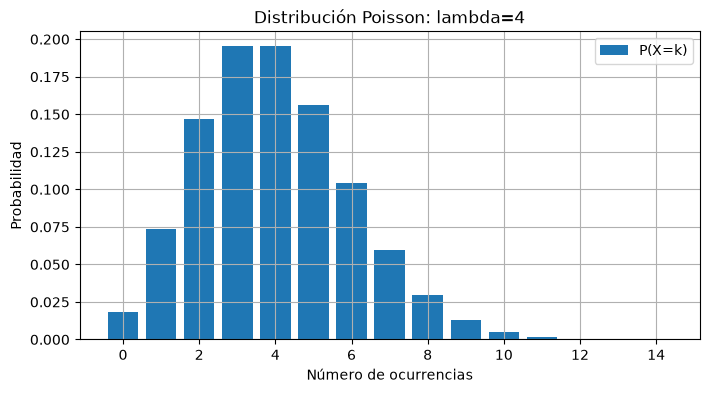

P(X = 6) = 0.1042
E(X) = 4.0000
Var(X) = 4.0000


In [26]:
# Poisson: número de llamadas por hora.
lam = 4
k = np.arange(0, 15)
pmf = stats.poisson.pmf(k, lam)

prob_seis_llamadas = stats.poisson.pmf(6, lam)

plt.figure()
plt.bar(k, pmf, label="P(X=k)")
plt.title("Distribución Poisson: lambda=4")
plt.xlabel("Número de ocurrencias")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X = 6) = {prob_seis_llamadas:.4f}")
print(f"E(X) = {lam:.4f}")
print(f"Var(X) = {lam:.4f}")

### 2.6 Binomial negativa

La distribución **binomial negativa** puede modelar el número de fracasos antes de obtener $r$ éxitos en ensayos Bernoulli independientes. Esta parametrización es frecuente en textos clásicos de probabilidad.

Si $X$ es el número de fracasos antes de $r$ éxitos, entonces:

$$
P(X=k)=\binom{k+r-1}{k}(1-p)^k p^r,
\qquad k=0,1,2,\ldots
$$

**Propiedades:**

- Generaliza la distribución geométrica.
- Cuenta fracasos antes de un número fijo de éxitos.
- Requiere ensayos independientes con probabilidad de éxito constante.

**Esperanza:**

$$
E(X)=\frac{r(1-p)}{p}.
$$

**Varianza:**

$$
Var(X)=\frac{r(1-p)}{p^2}.
$$

**Ejercicio adicional:** si se desea obtener $r=3$ éxitos con $p=0.4$, calcular la probabilidad de observar 5 fracasos antes del tercer éxito.

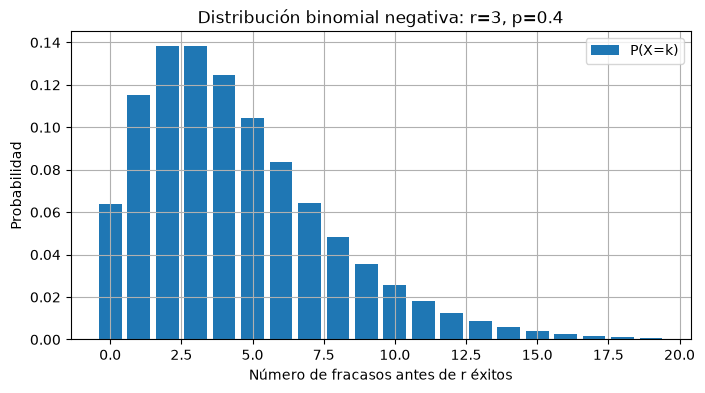

P(X = 5) = 0.1045
E(X) = 4.5000
Var(X) = 11.2500


In [27]:
# Binomial negativa: fracasos antes de r éxitos.
r, p = 3, 0.4
k = np.arange(0, 20)
pmf = stats.nbinom.pmf(k, r, p)

prob_5_fracasos = stats.nbinom.pmf(5, r, p)

plt.figure()
plt.bar(k, pmf, label="P(X=k)")
plt.title("Distribución binomial negativa: r=3, p=0.4")
plt.xlabel("Número de fracasos antes de r éxitos")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X = 5) = {prob_5_fracasos:.4f}")
print(f"E(X) = {r * (1 - p) / p:.4f}")
print(f"Var(X) = {r * (1 - p) / p**2:.4f}")

### 2.7 Hipergeométrica

La distribución **hipergeométrica** modela el número de éxitos al extraer una muestra sin reemplazo de una población finita. Es especialmente útil cuando las extracciones no son independientes.

Sea:

- $N$: tamaño de la población.
- $K$: número de éxitos en la población.
- $n$: tamaño de la muestra.
- $X$: número de éxitos observados en la muestra.

Entonces:

$$
P(X=k)=\frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}.
$$

**Propiedades:**

- Las extracciones son sin reemplazo.
- La población es finita.
- La probabilidad cambia después de cada extracción.

**Esperanza:**

$$
E(X)=n\frac{K}{N}.
$$

**Varianza:**

$$
Var(X)=n\frac{K}{N}\left(1-\frac{K}{N}\right)\frac{N-n}{N-1}.
$$

**Ejercicio adicional:** en una población de 50 productos hay 8 defectuosos. Si se extraen 10 sin reemplazo, calcular $P(X=2)$.

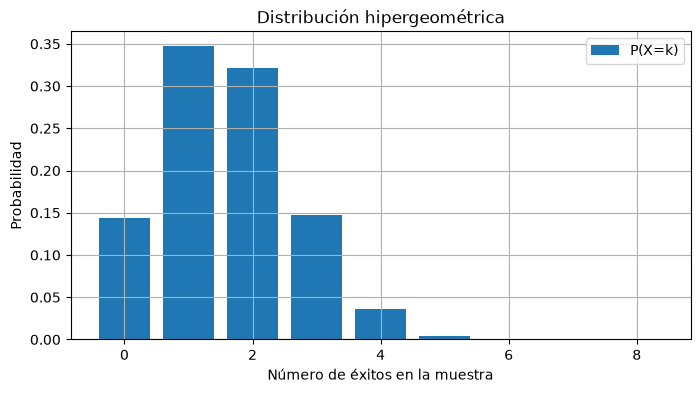

P(X = 2) = 0.3217
E(X) = 1.6000
Var(X) = 1.0971


In [28]:
# Hipergeométrica: productos defectuosos en una muestra sin reemplazo.
N_poblacion = 50
K_exitos = 8
n_muestra = 10

k_min = max(0, n_muestra - (N_poblacion - K_exitos))
k_max = min(K_exitos, n_muestra)
k = np.arange(k_min, k_max + 1)

pmf = stats.hypergeom.pmf(k, N_poblacion, K_exitos, n_muestra)
prob_dos_defectuosos = stats.hypergeom.pmf(2, N_poblacion, K_exitos, n_muestra)

media = n_muestra * K_exitos / N_poblacion
varianza = n_muestra * (K_exitos / N_poblacion) * (1 - K_exitos / N_poblacion) * ((N_poblacion - n_muestra) / (N_poblacion - 1))

plt.figure()
plt.bar(k, pmf, label="P(X=k)")
plt.title("Distribución hipergeométrica")
plt.xlabel("Número de éxitos en la muestra")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

print(f"P(X = 2) = {prob_dos_defectuosos:.4f}")
print(f"E(X) = {media:.4f}")
print(f"Var(X) = {varianza:.4f}")

## 3. Variables aleatorias continuas

Una variable aleatoria continua puede tomar valores en intervalos de la recta real. Su distribución se describe mediante una **función de densidad** $f_X(x)$.

La probabilidad de que $X$ caiga en un intervalo se calcula como:

$$
P(a\leq X\leq b)=\int_a^b f_X(x)\,dx.
$$

Para una densidad válida:

$$
f_X(x)\geq 0
$$

y

$$
\int_{-\infty}^{\infty} f_X(x)\,dx=1.
$$

A continuación se presentan las distribuciones continuas mínimas solicitadas. Cada una se separa como subsubtema.

### 3.1 Uniforme continua

Una variable aleatoria tiene distribución **uniforme continua** en el intervalo $(a,b)$ cuando todos los subintervalos de la misma longitud tienen la misma probabilidad.

Su función de densidad es:

$$
f_X(x)=
\begin{cases}
\frac{1}{b-a}, & a\leq x\leq b,\\
0, & \text{en otro caso}.
\end{cases}
$$

Su función de distribución es:

$$
F_X(x)=
\begin{cases}
0, & x<a,\\
\frac{x-a}{b-a}, & a\leq x\leq b,\\
1, & x>b.
\end{cases}
$$

**Esperanza:**

$$
E(X)=\frac{a+b}{2}.
$$

**Varianza:**

$$
Var(X)=\frac{(b-a)^2}{12}.
$$

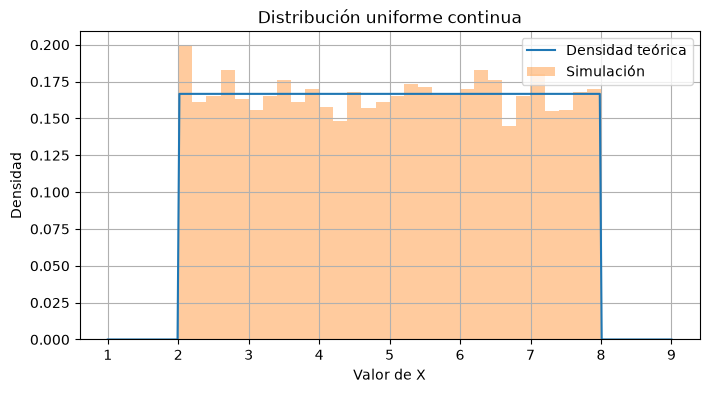

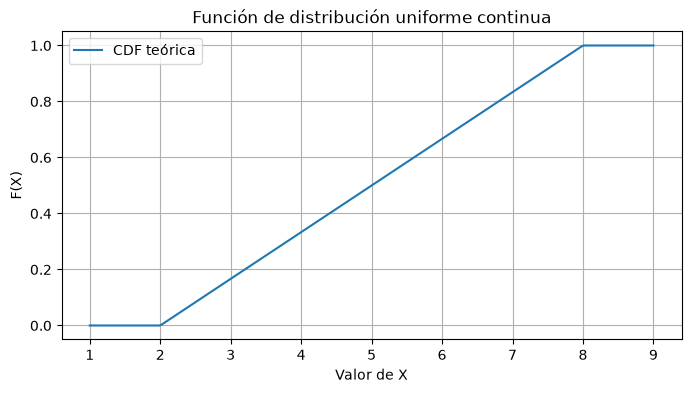

Media teórica = 5.0000
Media simulada = 4.9848
Varianza teórica = 3.0000
Varianza simulada = 3.0341


In [29]:
# Uniforme continua en el intervalo [2, 8].
a, b = 2, 8
x = np.linspace(a - 1, b + 1, 300)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)
cdf = stats.uniform.cdf(x, loc=a, scale=b-a)

# Simulación.
muestra = stats.uniform.rvs(loc=a, scale=b-a, size=5000, random_state=123)

plt.figure()
plt.plot(x, pdf, label="Densidad teórica")
plt.hist(muestra, bins=30, density=True, alpha=0.4, label="Simulación")
plt.title("Distribución uniforme continua")
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, cdf, label="CDF teórica")
plt.title("Función de distribución uniforme continua")
plt.xlabel("Valor de X")
plt.ylabel("F(X)")
plt.legend()
plt.show()

print(f"Media teórica = {(a + b) / 2:.4f}")
print(f"Media simulada = {np.mean(muestra):.4f}")
print(f"Varianza teórica = {(b - a)**2 / 12:.4f}")
print(f"Varianza simulada = {np.var(muestra, ddof=0):.4f}")

### 3.2 Normal

La distribución **normal** es una de las distribuciones más importantes en probabilidad y estadística. Se usa para modelar fenómenos con variación alrededor de una media y aparece de manera central en el Teorema Central del Límite.

Si $X\sim N(\mu,\sigma^2)$, su densidad es:

$$
f_X(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}.
$$

La función de distribución no tiene una forma cerrada elemental, pero se calcula numéricamente.

**Esperanza:**

$$
E(X)=\mu.
$$

**Varianza:**

$$
Var(X)=\sigma^2.
$$

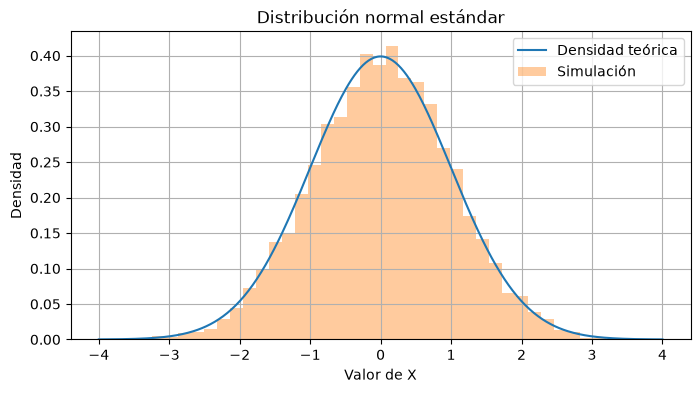

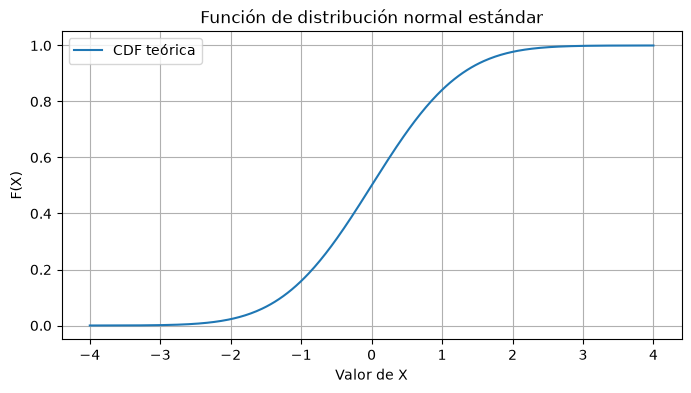

Media teórica = 0.0000
Media simulada = 0.0211
Varianza teórica = 1.0000
Varianza simulada = 0.9757


In [30]:
# Normal con media 0 y desviación estándar 1.
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
cdf = stats.norm.cdf(x, loc=mu, scale=sigma)

# Simulación.
muestra = stats.norm.rvs(loc=mu, scale=sigma, size=5000, random_state=123)

plt.figure()
plt.plot(x, pdf, label="Densidad teórica")
plt.hist(muestra, bins=40, density=True, alpha=0.4, label="Simulación")
plt.title("Distribución normal estándar")
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, cdf, label="CDF teórica")
plt.title("Función de distribución normal estándar")
plt.xlabel("Valor de X")
plt.ylabel("F(X)")
plt.legend()
plt.show()

print(f"Media teórica = {mu:.4f}")
print(f"Media simulada = {np.mean(muestra):.4f}")
print(f"Varianza teórica = {sigma**2:.4f}")
print(f"Varianza simulada = {np.var(muestra, ddof=0):.4f}")

### 3.3 Exponencial

La distribución **exponencial** se usa para modelar tiempos de espera entre eventos cuando ocurren con tasa constante. Es una distribución continua relacionada con el proceso de Poisson.

Si $X\sim Exp(\lambda)$, su densidad es:

$$
f_X(x)=\lambda e^{-\lambda x}, \qquad x\geq 0.
$$

Su función de distribución es:

$$
F_X(x)=1-e^{-\lambda x}, \qquad x\geq 0.
$$

**Esperanza:**

$$
E(X)=\frac{1}{\lambda}.
$$

**Varianza:**

$$
Var(X)=\frac{1}{\lambda^2}.
$$

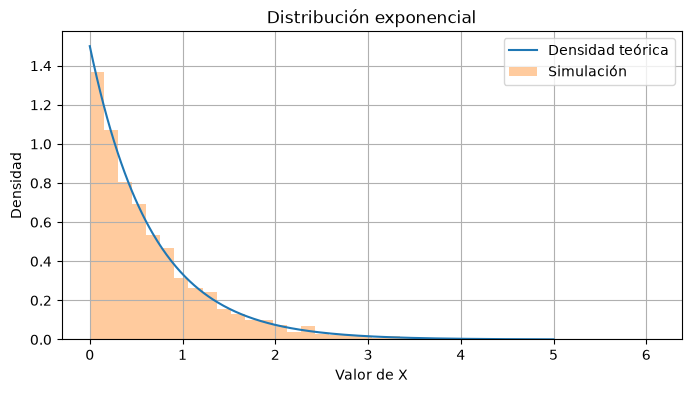

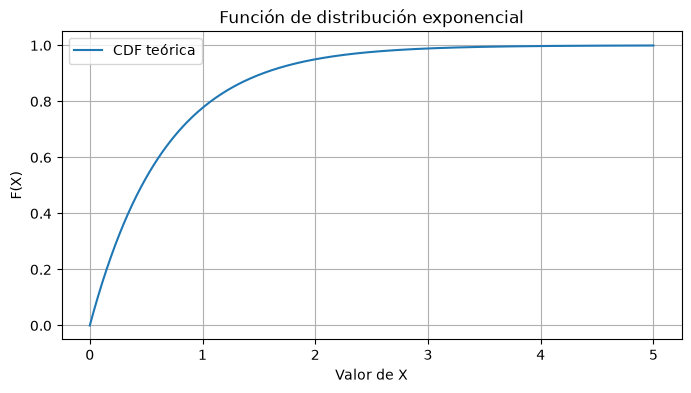

Media teórica = 0.6667
Media simulada = 0.6609
Varianza teórica = 0.4444
Varianza simulada = 0.4336


In [31]:
# Exponencial con tasa lambda.
lam = 1.5
x = np.linspace(0, 5, 400)
pdf = stats.expon.pdf(x, scale=1/lam)
cdf = stats.expon.cdf(x, scale=1/lam)

# Simulación.
muestra = stats.expon.rvs(scale=1/lam, size=5000, random_state=123)

plt.figure()
plt.plot(x, pdf, label="Densidad teórica")
plt.hist(muestra, bins=40, density=True, alpha=0.4, label="Simulación")
plt.title("Distribución exponencial")
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, cdf, label="CDF teórica")
plt.title("Función de distribución exponencial")
plt.xlabel("Valor de X")
plt.ylabel("F(X)")
plt.legend()
plt.show()

print(f"Media teórica = {1 / lam:.4f}")
print(f"Media simulada = {np.mean(muestra):.4f}")
print(f"Varianza teórica = {1 / lam**2:.4f}")
print(f"Varianza simulada = {np.var(muestra, ddof=0):.4f}")

### 3.4 Gamma

La distribución **gamma** generaliza a la exponencial. Se usa para modelar tiempos acumulados hasta que ocurren varios eventos. Bajo la parametrización con forma $\alpha$ y tasa $\lambda$, su densidad es:

$$
f_X(x)=\frac{\lambda^\alpha}{\Gamma(\alpha)}
x^{\alpha-1}e^{-\lambda x}, \qquad x>0.
$$

Su función de distribución se expresa mediante la función gamma incompleta, por lo que normalmente se calcula numéricamente.

**Esperanza:**

$$
E(X)=\frac{\alpha}{\lambda}.
$$

**Varianza:**

$$
Var(X)=\frac{\alpha}{\lambda^2}.
$$

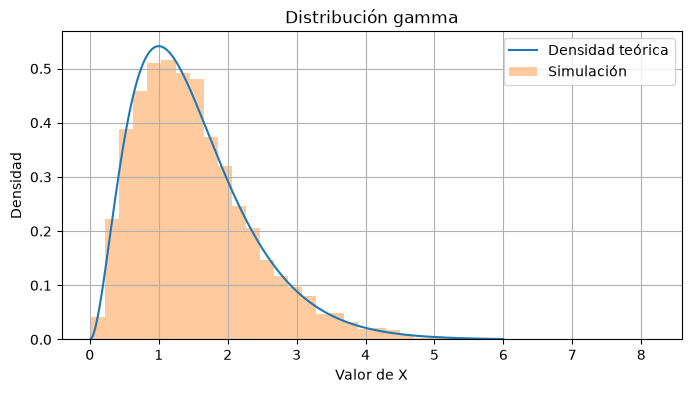

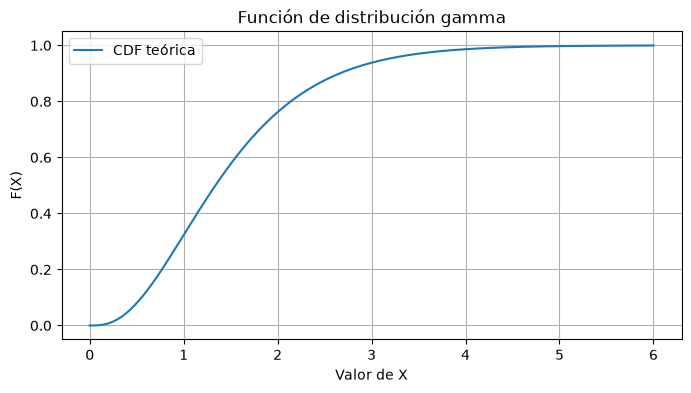

Media teórica = 1.5000
Media simulada = 1.5194
Varianza teórica = 0.7500
Varianza simulada = 0.7463


In [32]:
# Gamma con forma alpha y tasa lambda.
alpha, lam = 3, 2
x = np.linspace(0, 6, 400)
pdf = stats.gamma.pdf(x, a=alpha, scale=1/lam)
cdf = stats.gamma.cdf(x, a=alpha, scale=1/lam)

# Simulación.
muestra = stats.gamma.rvs(a=alpha, scale=1/lam, size=5000, random_state=123)

plt.figure()
plt.plot(x, pdf, label="Densidad teórica")
plt.hist(muestra, bins=40, density=True, alpha=0.4, label="Simulación")
plt.title("Distribución gamma")
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, cdf, label="CDF teórica")
plt.title("Función de distribución gamma")
plt.xlabel("Valor de X")
plt.ylabel("F(X)")
plt.legend()
plt.show()

print(f"Media teórica = {alpha / lam:.4f}")
print(f"Media simulada = {np.mean(muestra):.4f}")
print(f"Varianza teórica = {alpha / lam**2:.4f}")
print(f"Varianza simulada = {np.var(muestra, ddof=0):.4f}")

## 4. Simulación de variables aleatorias

La simulación permite generar observaciones artificiales de una distribución para aproximar probabilidades, medias, varianzas y formas de distribución.

En esta sección se compara la teoría con la simulación. La idea es observar que, con muestras grandes, los valores simulados se acercan a los valores teóricos.

### 4.1 Transformada inversa

El método de la **transformada inversa** parte de una variable:

$$
U\sim Uniforme(0,1)
$$

y define:

$$
X=F^{-1}(U),
$$

donde $F^{-1}$ es la inversa de la función de distribución acumulada.

Para una variable exponencial con tasa $\lambda$:

$$
F(x)=1-e^{-\lambda x}.
$$

Si $U=F(x)$, entonces:

$$
X=-\frac{\ln(1-U)}{\lambda}.
$$

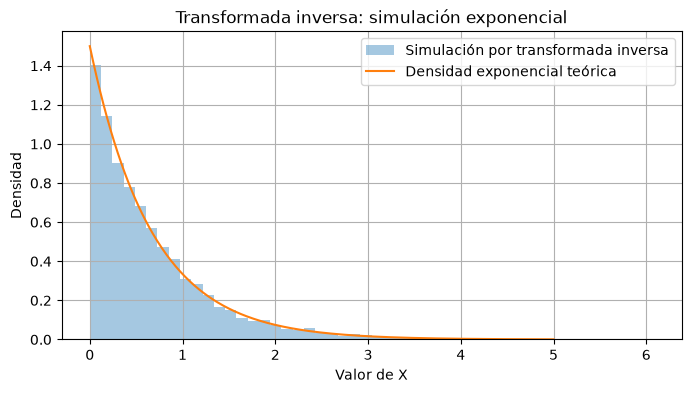

Media teórica = 0.6667
Media simulada = 0.6583
Varianza teórica = 0.4444
Varianza simulada = 0.4220


In [33]:
# Transformada inversa para simular una exponencial.
lam = 1.5
n = 10000

U = np.random.uniform(0, 1, n)
X_inv = -np.log(1 - U) / lam

x = np.linspace(0, 5, 400)
pdf_teorica = stats.expon.pdf(x, scale=1/lam)

plt.figure()
plt.hist(X_inv, bins=50, density=True, alpha=0.4, label="Simulación por transformada inversa")
plt.plot(x, pdf_teorica, label="Densidad exponencial teórica")
plt.title("Transformada inversa: simulación exponencial")
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.legend()
plt.show()

print(f"Media teórica = {1 / lam:.4f}")
print(f"Media simulada = {np.mean(X_inv):.4f}")
print(f"Varianza teórica = {1 / lam**2:.4f}")
print(f"Varianza simulada = {np.var(X_inv, ddof=0):.4f}")

**Interpretación:** la gráfica compara el histograma de valores simulados mediante transformada inversa contra la densidad teórica exponencial. Como la muestra es grande, el histograma se parece a la curva teórica y la media/varianza simuladas se aproximan a sus valores esperados.

### 4.2 Comparación entre teoría y simulación: binomial

Ahora se simula una binomial y se compara la frecuencia relativa observada con la función de probabilidad teórica.

La comparación permite verificar que, cuando aumenta el número de simulaciones, las frecuencias relativas tienden a acercarse a las probabilidades teóricas.

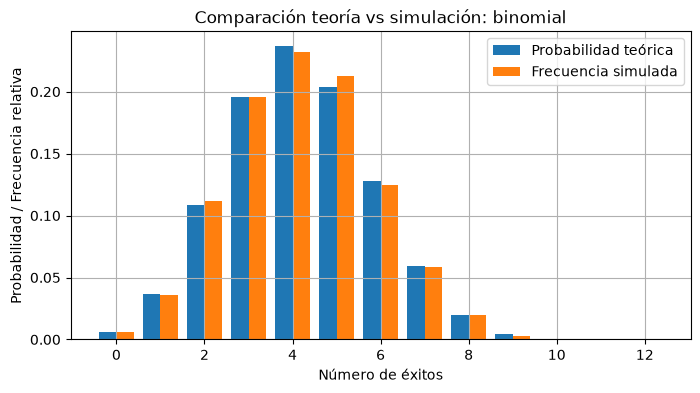

,k,P_teorica,Frecuencia_simulada
0,0,0.005688,0.0063
1,1,0.036753,0.0361
2,2,0.108846,0.1114
3,3,0.195365,0.1954
4,4,0.236692,0.2318
5,5,0.203920,0.2125
6,6,0.128103,0.1244
7,7,0.059125,0.0586
8,8,0.019898,0.0196
9,9,0.004762,0.0032


In [34]:
# Comparación teoría vs simulación para una binomial.
n, p = 12, 0.35
m = 10000

simulacion = stats.binom.rvs(n=n, p=p, size=m, random_state=123)
valores = np.arange(0, n + 1)

pmf_teorica = stats.binom.pmf(valores, n, p)
frecuencias_simuladas = np.array([(simulacion == k).mean() for k in valores])

plt.figure()
plt.bar(valores - 0.2, pmf_teorica, width=0.4, label="Probabilidad teórica")
plt.bar(valores + 0.2, frecuencias_simuladas, width=0.4, label="Frecuencia simulada")
plt.title("Comparación teoría vs simulación: binomial")
plt.xlabel("Número de éxitos")
plt.ylabel("Probabilidad / Frecuencia relativa")
plt.legend()
plt.show()

comparacion = pd.DataFrame({
    "k": valores,
    "P_teorica": pmf_teorica,
    "Frecuencia_simulada": frecuencias_simuladas
})

comparacion.head(10)

**Interpretación:** las barras simuladas son cercanas a las barras teóricas. Las diferencias pequeñas se deben al azar de la simulación; si se incrementa el número de repeticiones, la aproximación suele mejorar.

## 5. Función generadora de momentos (FGM)

La **función generadora de momentos** de una variable aleatoria $X$ se define como:

$$
M_X(t)=E(e^{tX}).
$$

Cuando existe alrededor de $t=0$, permite obtener momentos mediante derivadas:

$$
E(X)=M'_X(0),
$$

$$
E(X^2)=M''_X(0).
$$

Por lo tanto:

$$
Var(X)=E(X^2)-[E(X)]^2.
$$

**Propiedades principales:**

- $M_X(0)=1$.
- Si existe en un intervalo alrededor de cero, caracteriza la distribución.
- Para variables independientes, la FGM de la suma es el producto de las FGM.
- Sus derivadas evaluadas en cero generan momentos.

**Ejemplo:** FGM de una Bernoulli con parámetro $p$:

$$
M_X(t)=E(e^{tX})=(1-p)+pe^t.
$$

In [35]:
# Obtención de momentos con Sympy para una Bernoulli(p).
t, p = sp.symbols("t p", positive=True)

M = (1 - p) + p * sp.exp(t)

primer_momento = sp.diff(M, t).subs(t, 0)
segundo_momento = sp.diff(M, t, 2).subs(t, 0)
varianza = sp.simplify(segundo_momento - primer_momento**2)

print("FGM de Bernoulli:")
display(M)

print("E(X):")
display(primer_momento)

print("E(X^2):")
display(segundo_momento)

print("Var(X):")
display(varianza)

FGM de Bernoulli:


p*exp(t) - p + 1

E(X):


p

E(X^2):


p

Var(X):


p*(1 - p)

**Interpretación:** al derivar la FGM de Bernoulli se obtiene $E(X)=p$ y $E(X^2)=p$. Por eso, la varianza resulta $p(1-p)$.

## 6. Función característica (FC)

La **función característica** de una variable aleatoria $X$ se define como:

$$
\varphi_X(t)=E(e^{itX}),
$$

donde $i$ es la unidad imaginaria.

A diferencia de la FGM, la función característica siempre existe, porque:

$$
|e^{itX}|=1.
$$

Además, caracteriza completamente la distribución.

**Propiedades principales:**

- $\varphi_X(0)=1$.
- Siempre existe.
- Caracteriza completamente la distribución.
- Si los momentos existen, se relaciona con ellos mediante derivadas.
- Para variables independientes, la función característica de la suma es el producto de las funciones características.

La relación con los momentos es:

$$
\varphi_X'(0)=iE(X),
$$

y

$$
\varphi_X''(0)=-E(X^2).
$$

**Ejemplo:** función característica de una Bernoulli con parámetro $p$:

$$
\varphi_X(t)=(1-p)+pe^{it}.
$$

In [36]:
# Función característica de Bernoulli(p) y relación con momentos.
t, p = sp.symbols("t p", real=True)
i = sp.I

phi = (1 - p) + p * sp.exp(i * t)

phi_prima_0 = sp.diff(phi, t).subs(t, 0)
phi_segunda_0 = sp.diff(phi, t, 2).subs(t, 0)

EX_desde_fc = sp.simplify(phi_prima_0 / i)
EX2_desde_fc = sp.simplify(-phi_segunda_0)

print("Función característica de Bernoulli:")
display(phi)

print("E(X) usando FC:")
display(EX_desde_fc)

print("E(X^2) usando FC:")
display(EX2_desde_fc)

Función característica de Bernoulli:


p*exp(I*t) - p + 1

E(X) usando FC:


p

E(X^2) usando FC:


p

**Interpretación:** la función característica entrega los mismos momentos que la FGM cuando los momentos existen. Su ventaja teórica es que siempre existe y permite caracterizar completamente la distribución.

## 7. Ley de los Grandes Números

La **Ley de los Grandes Números** establece que el promedio muestral se aproxima a la esperanza de la variable aleatoria cuando el tamaño de la muestra crece.

Si $X_1,X_2,\ldots,X_n$ son variables independientes e idénticamente distribuidas con esperanza $\mu$, entonces el promedio:

$$
\bar{X}_n=\frac{1}{n}\sum_{i=1}^{n}X_i
$$

tiende a aproximarse a:

$$
\mu=E(X).
$$

En la simulación se usará una variable Bernoulli con $p=0.35$, cuya esperanza es $E(X)=p$.

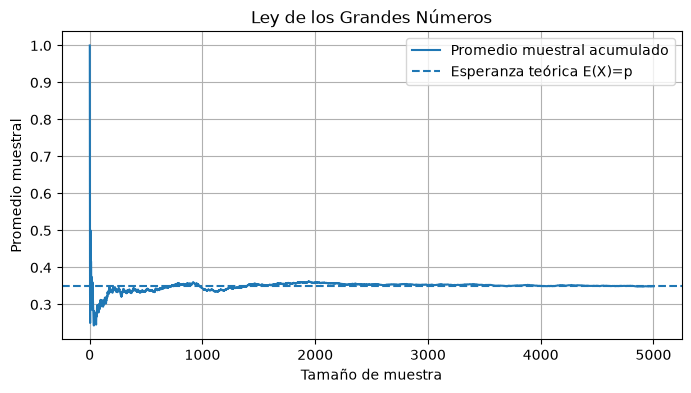

Promedio final simulado = 0.3492
Esperanza teórica = 0.3500


In [37]:
# Simulación de la Ley de los Grandes Números con Bernoulli(p).
p = 0.35
n = 5000

muestra = stats.bernoulli.rvs(p, size=n, random_state=123)
promedios_acumulados = np.cumsum(muestra) / np.arange(1, n + 1)

plt.figure()
plt.plot(np.arange(1, n + 1), promedios_acumulados, label="Promedio muestral acumulado")
plt.axhline(p, linestyle="--", label="Esperanza teórica E(X)=p")
plt.title("Ley de los Grandes Números")
plt.xlabel("Tamaño de muestra")
plt.ylabel("Promedio muestral")
plt.legend()
plt.show()

print(f"Promedio final simulado = {promedios_acumulados[-1]:.4f}")
print(f"Esperanza teórica = {p:.4f}")

**Interpretación:** al inicio el promedio muestral fluctúa bastante, porque hay pocos datos. Conforme aumenta el tamaño de la muestra, el promedio acumulado se estabiliza cerca de la esperanza teórica $0.35$.

## 8. Teorema Central del Límite

El **Teorema Central del Límite** indica que, bajo condiciones generales, la distribución de las medias muestrales se aproxima a una distribución normal cuando el tamaño de muestra es suficientemente grande.

Si $X_1,\ldots,X_n$ son variables independientes e idénticamente distribuidas con media $\mu$ y varianza $\sigma^2$, entonces:

$$
\bar{X}\approx N\left(\mu,\frac{\sigma^2}{n}\right)
$$

para $n$ grande.

En la simulación se usará una distribución exponencial, que no es normal. La idea es mostrar que, aunque los datos originales sean asimétricos, las medias muestrales se aproximan a una forma normal.

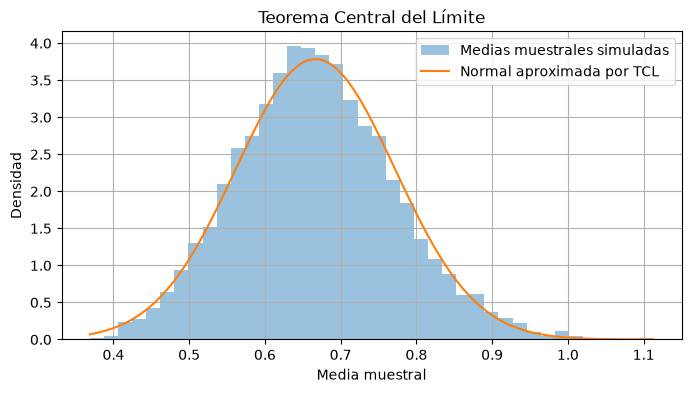

Media teórica de X = 0.6667
Media de medias simuladas = 0.6674
Desv. estándar teórica de medias = 0.1054
Desv. estándar simulada de medias = 0.1050


In [38]:
# Simulación del Teorema Central del Límite con datos exponenciales.
lam = 1.5
mu = 1 / lam
sigma = 1 / lam

tamano_muestra = 40
repeticiones = 6000

# Cada fila representa una muestra; se calcula la media de cada muestra.
muestras = stats.expon.rvs(scale=1/lam, size=(repeticiones, tamano_muestra), random_state=123)
medias_muestrales = muestras.mean(axis=1)

# Distribución normal aproximada de las medias.
x = np.linspace(medias_muestrales.min(), medias_muestrales.max(), 400)
normal_aprox = stats.norm.pdf(x, loc=mu, scale=sigma / np.sqrt(tamano_muestra))

plt.figure()
plt.hist(medias_muestrales, bins=40, density=True, alpha=0.45, label="Medias muestrales simuladas")
plt.plot(x, normal_aprox, label="Normal aproximada por TCL")
plt.title("Teorema Central del Límite")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.legend()
plt.show()

print(f"Media teórica de X = {mu:.4f}")
print(f"Media de medias simuladas = {np.mean(medias_muestrales):.4f}")
print(f"Desv. estándar teórica de medias = {sigma / np.sqrt(tamano_muestra):.4f}")
print(f"Desv. estándar simulada de medias = {np.std(medias_muestrales, ddof=0):.4f}")

**Interpretación:** el histograma de medias muestrales tiene forma aproximadamente normal. Además, la media de las medias simuladas se acerca a la media teórica de la exponencial y su desviación estándar se aproxima a $\sigma/\sqrt{n}$.

## 9. Conclusión

En este notebook se estudió cómo las variables aleatorias permiten representar numéricamente los resultados de un experimento aleatorio. Las variables discretas se describen mediante funciones de probabilidad, mientras que las continuas se describen mediante funciones de densidad y distribución acumulada.

Las distribuciones discretas revisadas —uniforme discreta, Bernoulli, binomial, geométrica, Poisson, binomial negativa e hipergeométrica— permiten modelar conteos, éxitos, fracasos, ocurrencias y extracciones sin reemplazo. Las distribuciones continuas —uniforme continua, normal, exponencial y gamma— permiten modelar valores en intervalos, fenómenos con variación alrededor de una media y tiempos de espera.

También se observó que la simulación en Python ayuda a comparar los resultados teóricos con datos generados artificialmente. La transformada inversa muestra cómo construir variables aleatorias a partir de una uniforme. La FGM y la FC son herramientas que resumen información de la distribución y permiten obtener momentos; la FC además siempre existe y caracteriza completamente la distribución.

Finalmente, la Ley de los Grandes Números muestra que los promedios muestrales se aproximan a la esperanza, mientras que el Teorema Central del Límite explica por qué las medias muestrales tienden a presentar comportamiento normal bajo condiciones generales. En conjunto, estos conceptos conectan distribuciones, momentos, simulación y resultados límite fundamentales de la probabilidad.

## 10. Bibliografía

- Rincón, L. **Curso intermedio de probabilidad**. Universidad Nacional Autónoma de México.
- Ross, S. M. **A First Course in Probability**. Pearson.
- Mood, A. M., Graybill, F. A. y Boes, D. C. **Introduction to the Theory of Statistics**. McGraw-Hill.
- Mendenhall, W., Beaver, R. J. y Beaver, B. M. **Introduction to Probability and Statistics**. Cengage Learning.